# Exploratory Data Analysis and Visualization

## Last-Mile Delivery Performance Analysis

This notebook performs exploratory data analysis and visualization
on a last-mile delivery logistics dataset.

The objective is to identify patterns, trends, relationships,
and anomalies in planned and actual delivery performance.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
print("Library loaded successfully")

Library loaded successfully


In [3]:
file_path = "../data/raw/routes_performance.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (249231, 16)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 249231 entries, 0 to 249230
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Route ID       249231 non-null  int64  
 1   Driver ID      249231 non-null  int64  
 2   Stop ID        249231 non-null  int64  
 3   Address ID     249231 non-null  int64  
 4   Week ID        249231 non-null  int64  
 5   Country        249231 non-null  int64  
 6   Day of Week    249231 non-null  str    
 7   IndexP         249231 non-null  int64  
 8   IndexA         249231 non-null  int64  
 9   Arrived Time   249231 non-null  float64
 10  Earliest Time  249231 non-null  float64
 11  Latest Time    249231 non-null  float64
 12  DistanceP      249231 non-null  float64
 13  DistanceA      249231 non-null  float64
 14  Depot          249231 non-null  int64  
 15  Delivery       249231 non-null  int64  
dtypes: float64(5), int64(10), str(1)
memory usage: 30.4 MB


In [5]:
print(df.columns.tolist())

['Route ID', 'Driver ID', 'Stop ID', 'Address ID', 'Week ID', 'Country', 'Day of Week', 'IndexP', 'IndexA', 'Arrived Time', 'Earliest Time', 'Latest Time', 'DistanceP', 'DistanceA', 'Depot', 'Delivery']


In [6]:
print(df.describe())

            Route ID      Driver ID        Stop ID     Address ID  \
count  249231.000000  249231.000000  249231.000000  249231.000000   
mean     9953.189110     152.393771    3737.926522    3345.477244   
std      5564.143548     109.178656    3393.794459    2795.870919   
min         0.000000       0.000000       0.000000       0.000000   
25%      5289.500000      54.000000     720.000000     829.000000   
50%     10065.000000     129.000000    2478.000000    2533.000000   
75%     14688.000000     264.000000    7236.000000    6184.000000   
max     19646.000000     399.000000   13124.000000   10863.000000   

             Week ID        Country         IndexP         IndexA  \
count  249231.000000  249231.000000  249231.000000  249231.000000   
mean       16.258375       0.648005       7.064165       7.064165   
std         8.708529       0.477593       5.397885       5.397885   
min         0.000000       0.000000       0.000000       0.000000   
25%         9.000000       0.0000

In [16]:
df["Route Deviation"]=df["DistanceA"]-df["DistanceP"]
print(df[["DistanceA","DistanceP","Route Deviation"]].head())

   DistanceA  DistanceP  Route Deviation
0   0.000000   0.000000         0.000000
1  16.329053  16.329053         0.000000
2   0.373110   0.373110         0.000000
3   0.000000   2.491915        -2.491915
4  13.944962   0.000000        13.944962


In [9]:
print("Average Route DEviation:",df["Route Deviation"].mean())
print("Minimum Route Deviation:",df["Route Deviation"].min())
print("Maximum Route DEviation:",df["Route Deviation"].max())

Average Route DEviation: -0.07571752012605275
Minimum Route Deviation: -408.954621738513
Maximum Route DEviation: 408.954621738513


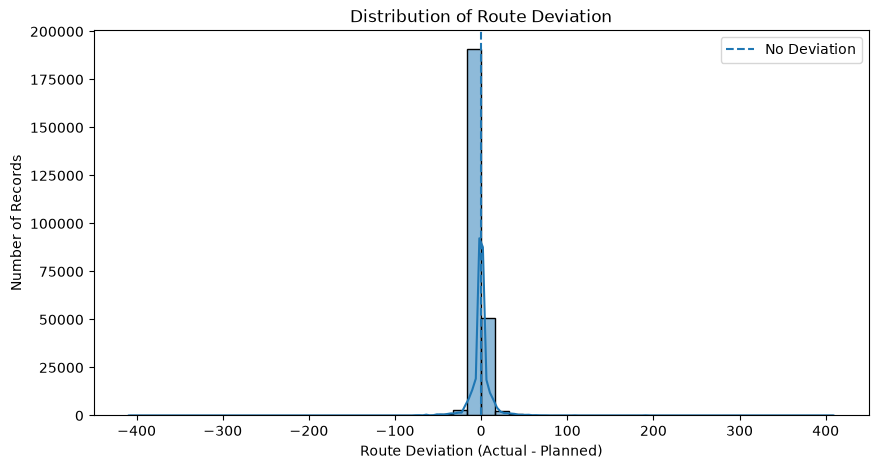

In [10]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Route Deviation"],
    bins=50,
    kde=True
)

plt.axvline(
    0,
    linestyle="--",
    label="No Deviation"
)

plt.title("Distribution of Route Deviation")
plt.xlabel("Route Deviation (Actual - Planned)")
plt.ylabel("Number of Records")
plt.legend()

plt.show()

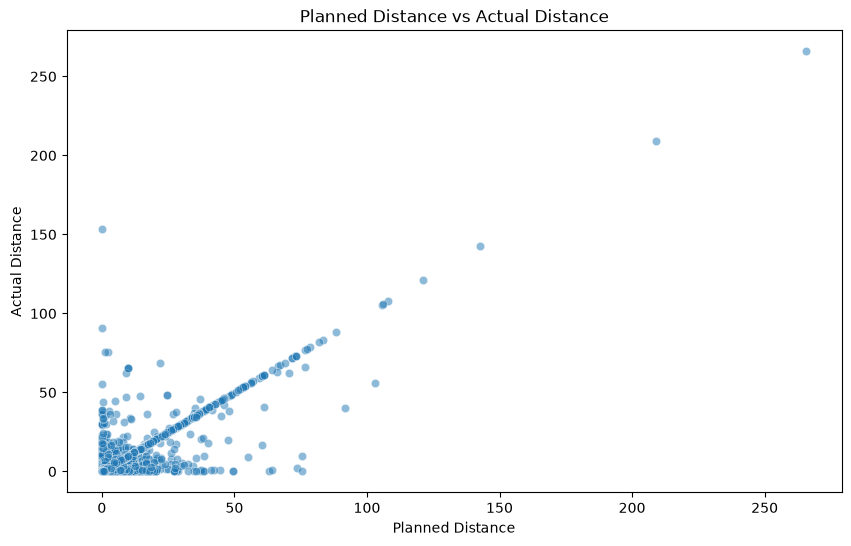

In [15]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x="DistanceP",
    y="DistanceA",
    alpha=0.5
)

plt.title("Planned Distance vs Actual Distance")
plt.xlabel("Planned Distance")
plt.ylabel("Actual Distance")

plt.show()

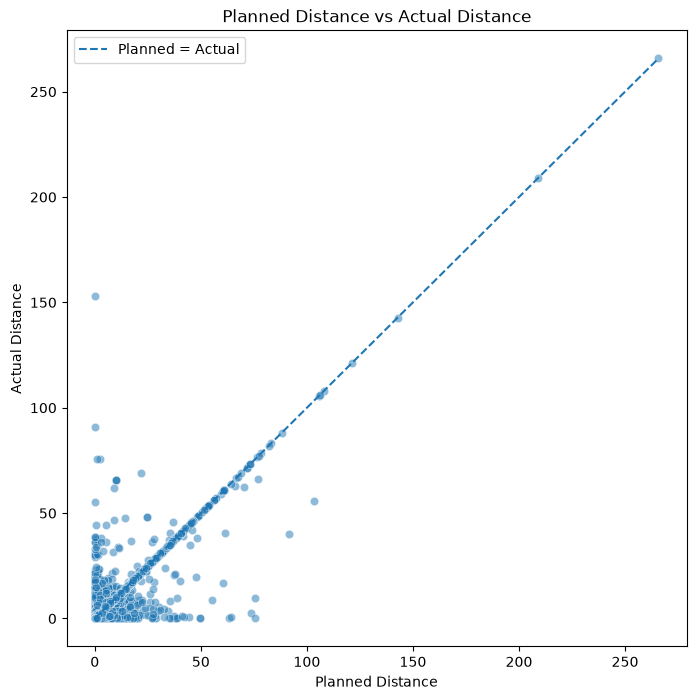

In [12]:
sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(8, 8))

sns.scatterplot(
    data=sample_df,
    x="DistanceP",
    y="DistanceA",
    alpha=0.5
)

max_distance = max(
    sample_df["DistanceP"].max(),
    sample_df["DistanceA"].max()
)

plt.plot(
    [0, max_distance],
    [0, max_distance],
    linestyle="--",
    label="Planned = Actual"
)

plt.title("Planned Distance vs Actual Distance")
plt.xlabel("Planned Distance")
plt.ylabel("Actual Distance")
plt.legend()

plt.show()

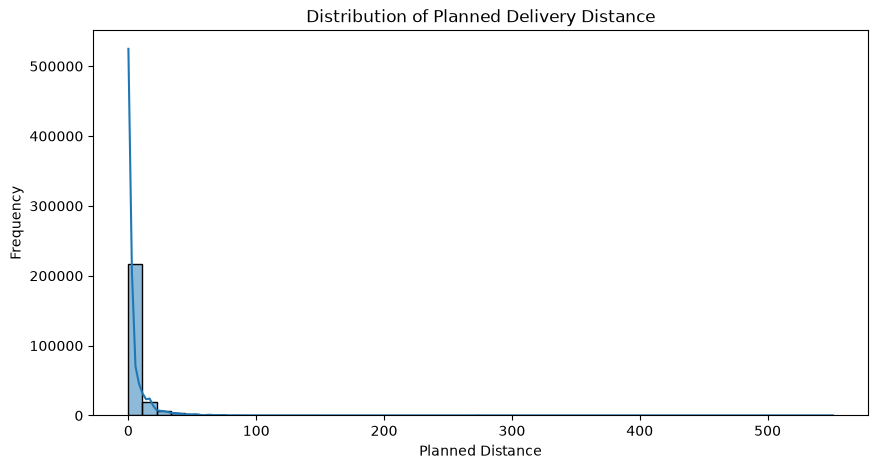

In [13]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["DistanceP"],
    bins=50,
    kde=True
)

plt.title("Distribution of Planned Delivery Distance")
plt.xlabel("Planned Distance")
plt.ylabel("Frequency")

plt.show()

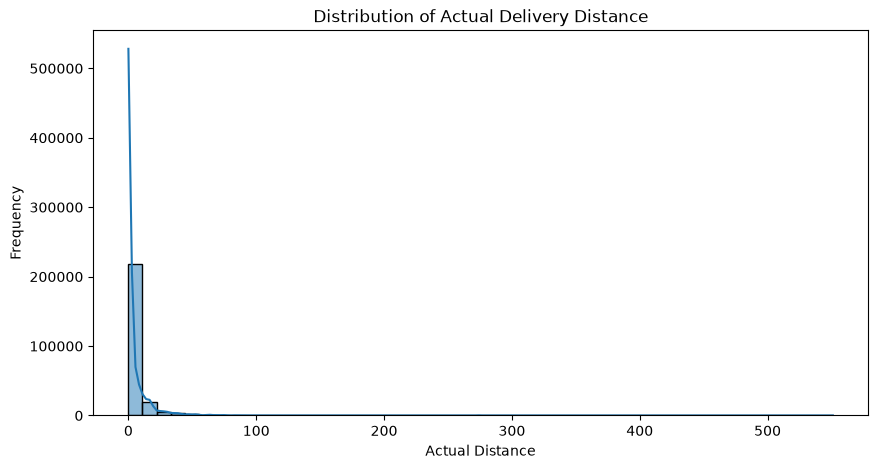

In [15]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["DistanceA"],
    bins=50,
    kde=True
)

plt.title("Distribution of Actual Delivery Distance")
plt.xlabel("Actual Distance")
plt.ylabel("Frequency")

plt.show()

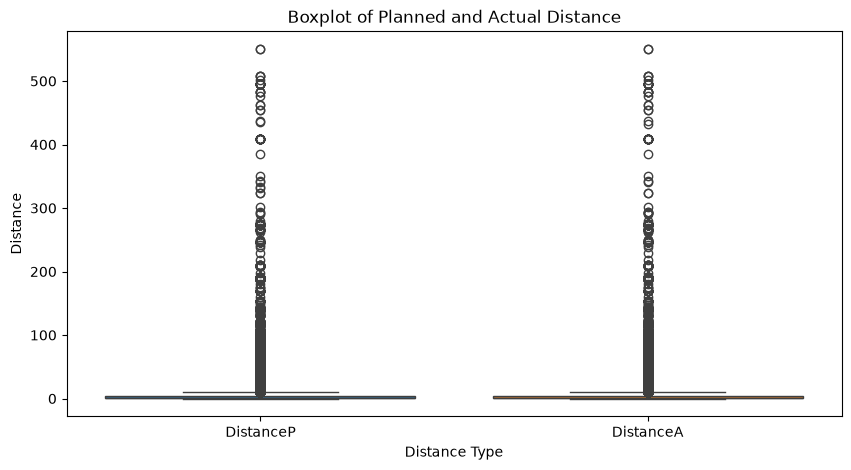

In [16]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df[
        ["DistanceP", "DistanceA"]
    ]
)

plt.title("Boxplot of Planned and Actual Distance")
plt.xlabel("Distance Type")
plt.ylabel("Distance")

plt.show()

In [17]:
df["Within Time Window"] = (
    (df["Arrived Time"] >= df["Earliest Time"]) &
    (df["Arrived Time"] <= df["Latest Time"])
)

In [19]:
print(
    df["Within Time Window"].value_counts()
)

Within Time Window
True     198225
False     51006
Name: count, dtype: int64


In [20]:
time_window_percentage = (
    df["Within Time Window"]
    .value_counts(normalize=True)
    * 100
)

print(time_window_percentage)

Within Time Window
True     79.534649
False    20.465351
Name: proportion, dtype: float64


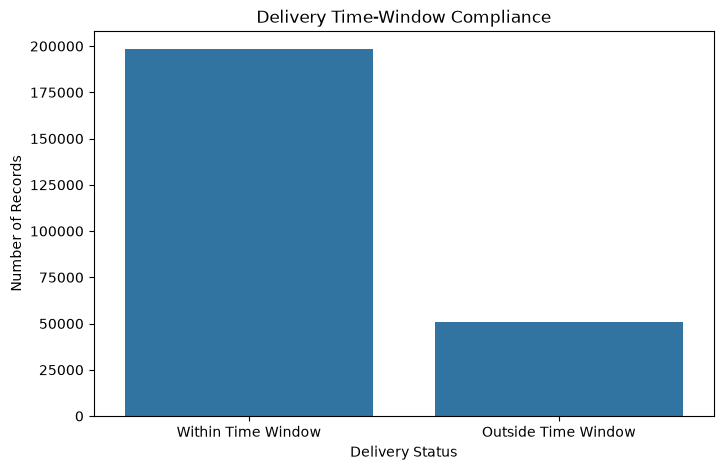

In [21]:
time_window_counts = (
    df["Within Time Window"]
    .value_counts()
)

labels = [
    "Within Time Window",
    "Outside Time Window"
]

values = [
    time_window_counts.get(True, 0),
    time_window_counts.get(False, 0)
]

plt.figure(figsize=(8, 5))

sns.barplot(
    x=labels,
    y=values
)

plt.title("Delivery Time-Window Compliance")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Records")

plt.show()

In [23]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_compliance = (
    df
    .groupby("Day of Week")["Within Time Window"]
    .mean()
    .mul(100)
    .reindex(day_order)
)

print(day_compliance)

Day of Week
Monday       79.134107
Tuesday      79.236884
Wednesday    79.219688
Thursday     80.622336
Friday       78.172969
Saturday     84.975520
Sunday       89.112903
Name: Within Time Window, dtype: float64


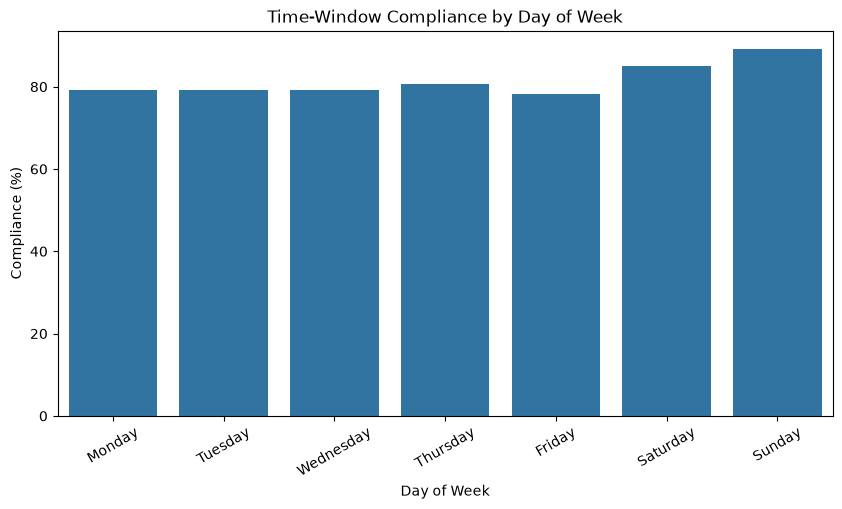

In [24]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=day_compliance.index,
    y=day_compliance.values
)

plt.title("Time-Window Compliance by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Compliance (%)")

plt.xticks(rotation=30)

plt.show()

In [25]:
country_counts = df["Country"].value_counts()
print(country_counts)

Country
1    161503
0     87728
Name: count, dtype: int64


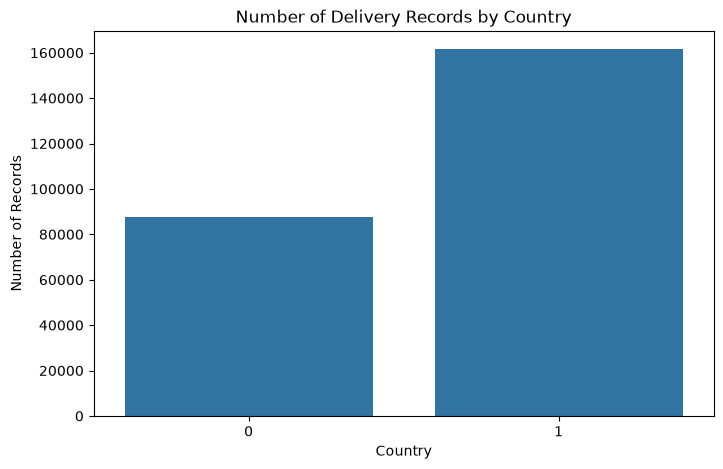

In [26]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=country_counts.index,
    y=country_counts.values
)

plt.title("Number of Delivery Records by Country")
plt.xlabel("Country")
plt.ylabel("Number of Records")

plt.show()

In [27]:
country_compliance = (
    df
    .groupby("Country")["Within Time Window"]
    .mean()
    .mul(100)
)

print(country_compliance)

Country
0    80.237780
1    79.152709
Name: Within Time Window, dtype: float64


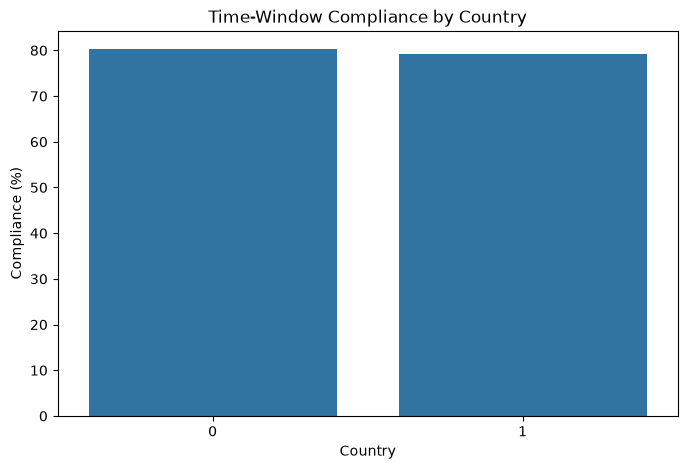

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=country_compliance.index,
    y=country_compliance.values
)

plt.title("Time-Window Compliance by Country")
plt.xlabel("Country")
plt.ylabel("Compliance (%)")

plt.show()

In [29]:
numeric_columns = [
    "IndexP",
    "IndexA",
    "Arrived Time",
    "Earliest Time",
    "Latest Time",
    "DistanceP",
    "DistanceA"
]

correlation = df[numeric_columns].corr()

print(correlation)

                 IndexP    IndexA  Arrived Time  Earliest Time  Latest Time  \
IndexP         1.000000  0.851428     -0.004193      -0.004266    -0.005000   
IndexA         0.851428  1.000000     -0.003955      -0.004236    -0.004974   
Arrived Time  -0.004193 -0.003955      1.000000       0.938326     0.938318   
Earliest Time -0.004266 -0.004236      0.938326       1.000000     0.999984   
Latest Time   -0.005000 -0.004974      0.938318       0.999984     1.000000   
DistanceP     -0.121548 -0.105152      0.004312       0.003674     0.004375   
DistanceA     -0.098120 -0.117941      0.004296       0.003144     0.003856   

               DistanceP  DistanceA  
IndexP         -0.121548  -0.098120  
IndexA         -0.105152  -0.117941  
Arrived Time    0.004312   0.004296  
Earliest Time   0.003674   0.003144  
Latest Time     0.004375   0.003856  
DistanceP       1.000000   0.865370  
DistanceA       0.865370   1.000000  


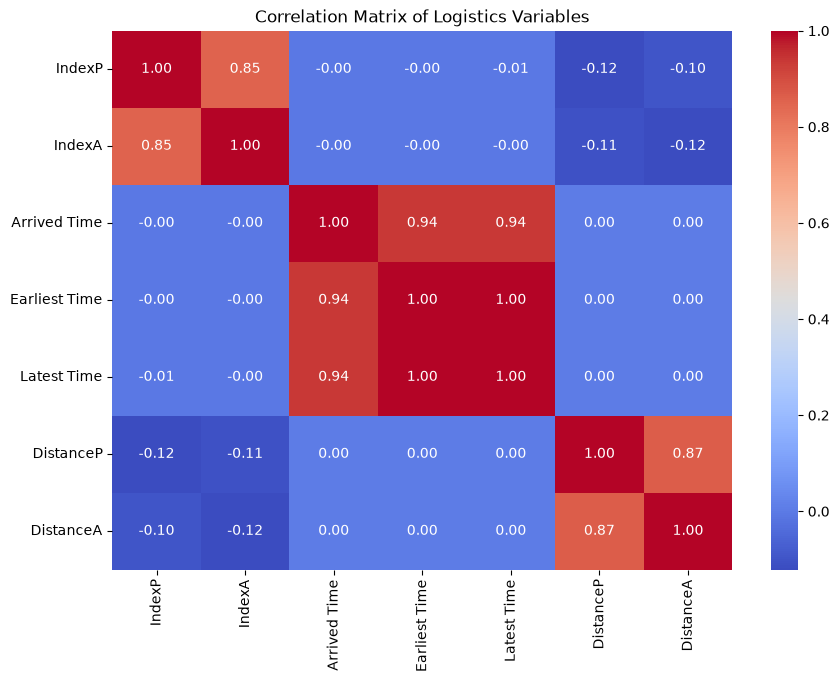

In [30]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Logistics Variables")

plt.show()

In [31]:
route_summary = (
    df
    .groupby("Route ID")
    .agg(
        Planned_Distance=("DistanceP", "sum"),
        Actual_Distance=("DistanceA", "sum"),
        Average_Arrival_Time=("Arrived Time", "mean"),
        Stops=("Stop ID", "count")
    )
)

route_summary["Route Deviation"] = (
    route_summary["Actual_Distance"]
    - route_summary["Planned_Distance"]
)

route_summary.head()

,Planned_Distance,Actual_Distance,Average_Arrival_Time,Stops,Route Deviation
Route ID,,,,,
0,49.468094,44.965197,263.363143,7,-4.502897
1,33.274342,33.610418,211.348857,7,0.336076
2,12.124804,12.508786,379.996429,7,0.383982
3,19.039848,19.374644,322.127400,10,0.334795
4,20.632674,19.528799,296.193125,8,-1.103875


In [32]:
print(route_summary.shape)

(19647, 5)


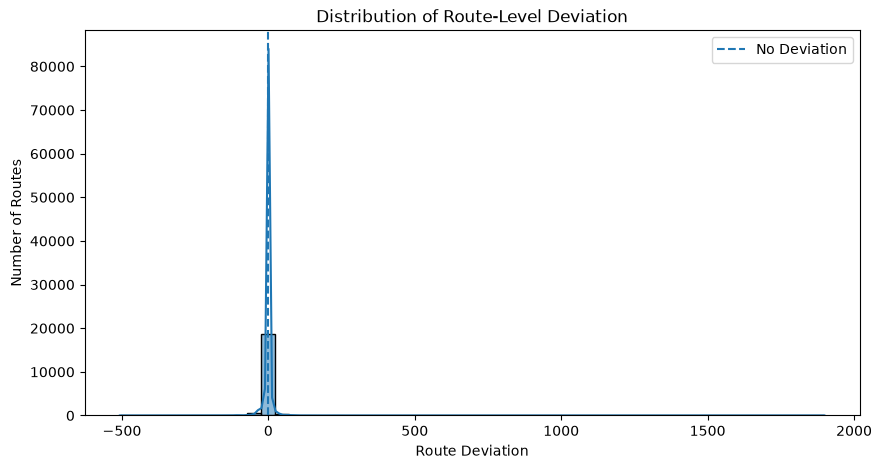

In [33]:
plt.figure(figsize=(10, 5))

sns.histplot(
    route_summary["Route Deviation"],
    bins=50,
    kde=True
)

plt.axvline(
    0,
    linestyle="--",
    label="No Deviation"
)

plt.title("Distribution of Route-Level Deviation")
plt.xlabel("Route Deviation")
plt.ylabel("Number of Routes")
plt.legend()

plt.show()

In [34]:
route_summary.sort_values(
    "Route Deviation",
    ascending=False
).head(10)

,Planned_Distance,Actual_Distance,Average_Arrival_Time,Stops,Route Deviation
Route ID,,,,,
18933,511.122760,2409.824486,72127.570385,13,1898.701726
9483,206.990890,946.097224,16053.712000,6,739.106334
4284,1562.584729,2162.240261,5713.995188,16,599.655533
16506,716.256106,1264.620952,1697.604444,9,548.364846
12280,1212.247600,1490.016533,2521.501636,11,277.768933
4176,901.224270,1175.293477,743.179500,4,274.069207
2403,1948.653027,2222.409264,816.915267,15,273.756237
9887,172.566647,407.652428,388.734917,12,235.085781
18924,77.239372,306.303803,67795.353400,10,229.064431


In [35]:
route_summary.sort_values(
    "Route Deviation",
    ascending=True
).head(10)

,Planned_Distance,Actual_Distance,Average_Arrival_Time,Stops,Route Deviation
Route ID,,,,,
9644,1554.971775,1047.864890,5119.373444,9,-507.106885
18768,818.284518,486.341728,28912.177000,4,-331.942791
6499,1290.567351,984.604720,2239.381833,12,-305.962631
564,414.120950,120.369533,390.382185,27,-293.751417
4371,345.192569,70.319106,499.849455,22,-274.873464
15968,336.048213,86.995030,23930.468500,8,-249.053183
15288,328.117609,88.099674,307.293833,6,-240.017935
1955,665.142304,446.606696,685.712250,16,-218.535608
13105,274.863365,77.617625,264.007500,12,-197.245740


In [36]:
print(df["Delivery"].value_counts())

Delivery
1    218006
0     31225
Name: count, dtype: int64


In [38]:
print(
    df.groupby("Delivery")["Within Time Window"].mean() * 100
)

Delivery
0    91.987190
1    77.751071
Name: Within Time Window, dtype: float64


In [39]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Columns",
        "Average Planned Distance",
        "Average Actual Distance",
        "Average Route Deviation",
        "Time-Window Compliance (%)"
    ],
    "Value": [
        len(df),
        len(df.columns),
        df["DistanceP"].mean(),
        df["DistanceA"].mean(),
        df["Route Deviation"].mean(),
        df["Within Time Window"].mean() * 100
    ]
})

eda_summary

,Metric,Value
0,Total Records,249231.000000
1,Total Columns,18.000000
2,Average Planned Distance,5.057804
3,Average Actual Distance,4.982086
4,Average Route Deviation,-0.075718
5,Time-Window Compliance (%),79.534649


In [40]:
route_summary.to_csv(
    "../outputs/results/route_summary.csv"
)

print("Route summary saved successfully!")

Route summary saved successfully!


In [41]:
eda_summary.to_csv(
    "../outputs/results/eda_summary.csv",
    index=False
)

print("EDA summary saved successfully!")

EDA summary saved successfully!


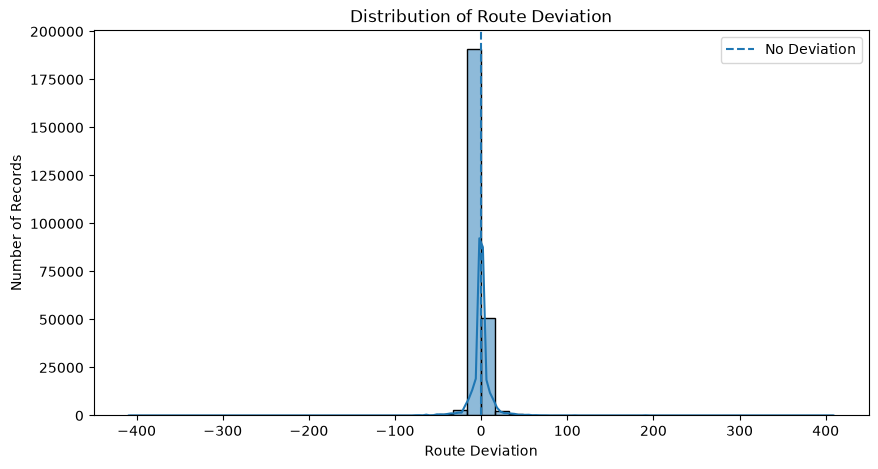

In [42]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Route Deviation"],
    bins=50,
    kde=True
)

plt.axvline(
    0,
    linestyle="--",
    label="No Deviation"
)

plt.title("Distribution of Route Deviation")
plt.xlabel("Route Deviation")
plt.ylabel("Number of Records")
plt.legend()

plt.savefig(
    "../outputs/figures/route_deviation_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Findings

1. The planned and actual delivery distances show measurable differences
   across the dataset.

2. Route deviation analysis helps identify records where actual travel
   differed from the planned route.

3. Time-window analysis shows that delivery performance is not identical
   across all records.

4. Day-wise analysis can reveal variations in delivery performance
   throughout the week.

5. Country-wise analysis provides a comparison of delivery performance
   across geographical groups represented in the dataset.

6. Correlation analysis helps identify relationships between important
   numerical logistics variables.

7. Route-level aggregation provides a broader view of route performance
   compared with individual stop-level analysis.

8. The identified patterns can be used as a foundation for future
   predictive modeling, clustering, and route optimization.

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Number of rows: 249231
Number of columns: 16

Column Names:
['Route ID', 'Driver ID', 'Stop ID', 'Address ID', 'Week ID', 'Country', 'Day of Week', 'IndexP', 'IndexA', 'Arrived Time', 'Earliest Time', 'Latest Time', 'DistanceP', 'DistanceA', 'Depot', 'Delivery']

Data Types:
Route ID           int64
Driver ID          int64
Stop ID            int64
Address ID         int64
Week ID            int64
Country            int64
Day of Week          str
IndexP             int64
IndexA             int64
Arrived Time     float64
Earliest Time    float64
Latest Time      float64
DistanceP        float64
DistanceA        float64
Depot              int64
Delivery           int64
dtype: object

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 249231 entries, 0 to 249230
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Route ID       249231 non-null  int64  
 1   Driver ID      249231 non-null  int64  
 2   Sto

,Route ID,Driver ID,Stop ID,Address ID,Week ID,Country,IndexP,IndexA,Arrived Time,Earliest Time,Latest Time,DistanceP,DistanceA,Depot,Delivery
count,249231.000000,249231.000000,249231.000000,249231.000000,249231.000000,249231.000000,249231.000000,249231.000000,2.492310e+05,2.492310e+05,2.492310e+05,249231.000000,249231.000000,249231.000000,249231.000000
mean,9953.189110,152.393771,3737.926522,3345.477244,16.258375,0.648005,7.064165,7.064165,1.242426e+03,9.717601e+02,1.334654e+03,5.057804,4.982086,0.112883,0.874715
std,5564.143548,109.178656,3393.794459,2795.870919,8.708529,0.477593,5.397885,5.397885,9.617329e+04,9.025393e+04,9.025539e+04,13.764297,13.816052,0.316451,0.331043
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,5289.500000,54.000000,720.000000,829.000000,9.000000,0.000000,3.000000,3.000000,2.952545e+02,1.800000e+02,4.800000e+02,0.140298,0.131887,0.000000,1.000000
50%,10065.000000,129.000000,2478.000000,2533.000000,17.000000,1.000000,6.000000,6.000000,3.918720e+02,2.700000e+02,5.700000e+02,0.936215,0.912488,0.000000,1.000000
75%,14688.000000,264.000000,7236.000000,6184.000000,23.000000,1.000000,11.000000,11.000000,5.014970e+02,3.600000e+02,7.200000e+02,4.489684,4.345968,0.000000,1.000000
max,19646.000000,399.000000,13124.000000,10863.000000,31.000000,1.000000,35.000000,35.000000,1.281432e+07,1.281018e+07,1.281054e+07,551.128575,551.128575,1.000000,1.000000


In [5]:
missing_values = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

print(missing_summary)

               Missing Values  Missing Percentage
Route ID                    0                 0.0
Driver ID                   0                 0.0
Stop ID                     0                 0.0
Address ID                  0                 0.0
Week ID                     0                 0.0
Country                     0                 0.0
Day of Week                 0                 0.0
IndexP                      0                 0.0
IndexA                      0                 0.0
Arrived Time                0                 0.0
Earliest Time               0                 0.0
Latest Time                 0                 0.0
DistanceP                   0                 0.0
DistanceA                   0                 0.0
Depot                       0                 0.0
Delivery                    0                 0.0


In [6]:
total_missing = df.isnull().sum().sum()

print("Total missing values:", total_missing)

if total_missing == 0:
    print("No missing values were found in the dataset.")
else:
    print("Missing values require further treatment.")

Total missing values: 0
No missing values were found in the dataset.


## 4. Duplicate Record Detection

Duplicate records can cause certain observations to be counted more than
once and may affect statistical analysis.

Therefore, exact duplicate records were identified before finalizing the
clean dataset.

In [7]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [8]:
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicate records were found.")

No duplicate records were found.


In [9]:
print("Duplicates after cleaning:", df.duplicated().sum())

Duplicates after cleaning: 0


## 5. Data Type Validation

Correct data types are important because incorrect types can produce
incorrect calculations.

For example:
- Distance should be numerical.
- Route ID should represent an identifier.
- Arrival and time-window values should be numerical or time-related.

In [10]:
print(df.dtypes)

Route ID           int64
Driver ID          int64
Stop ID            int64
Address ID         int64
Week ID            int64
Country            int64
Day of Week          str
IndexP             int64
IndexA             int64
Arrived Time     float64
Earliest Time    float64
Latest Time      float64
DistanceP        float64
DistanceA        float64
Depot              int64
Delivery           int64
dtype: object


In [11]:
numeric_columns = [
    "DistanceP",
    "DistanceA",
    "IndexP",
    "IndexA"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[numeric_columns].dtypes)

DistanceP    float64
DistanceA    float64
IndexP         int64
IndexA         int64
dtype: object


## 6. Invalid Value Detection

Data may contain values that are technically present but are not meaningful
for analysis.

For logistics data, negative distances would normally be invalid because
distance cannot be negative.

Therefore, planned and actual distances were checked for invalid negative
values.

In [12]:
print("Negative Planned Distances:",
      (df["DistanceP"] < 0).sum())

print("Negative Actual Distances:",
      (df["DistanceA"] < 0).sum())

Negative Planned Distances: 0
Negative Actual Distances: 0


## 7. Outlier Detection

Outliers are observations that are unusually far from the majority of the
data.

In logistics, an extreme distance may represent:
- an unusually long delivery route,
- a route deviation,
- a special delivery situation,
- or a possible data-entry problem.

Therefore, an outlier should not automatically be treated as an error.

The Interquartile Range (IQR) method was used to identify potentially
extreme values.

In [13]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]
    
    return Q1, Q3, IQR, lower_bound, upper_bound, outliers


for column in ["DistanceP", "DistanceA"]:
    
    Q1, Q3, IQR, lower, upper, outliers = detect_outliers_iqr(df, column)
    
    print("\nColumn:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)
    print("Number of Potential Outliers:", len(outliers))


Column: DistanceP
Q1: 0.1402980865271782
Q3: 4.489683877739779
IQR: 4.349385791212601
Lower Bound: -6.383780600291724
Upper Bound: 11.01376256455868
Number of Potential Outliers: 32597

Column: DistanceA
Q1: 0.1318865176473698
Q3: 4.345968177426673
IQR: 4.214081659779303
Lower Bound: -6.189235972021585
Upper Bound: 10.667090667095628
Number of Potential Outliers: 32773


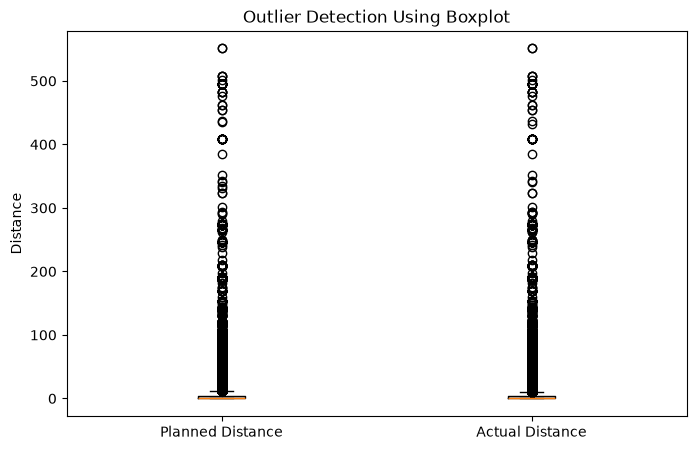

In [17]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [df["DistanceP"], df["DistanceA"]],
    tick_labels=["Planned Distance", "Actual Distance"]
)

plt.title("Outlier Detection Using Boxplot")
plt.ylabel("Distance")

plt.show()

The boxplot was used to visually inspect extreme observations in planned
and actual distances. Values outside the whiskers are potential outliers
according to the IQR method.

These observations were not automatically deleted because extreme logistics
routes can represent genuine operational situations. Removing them without
business justification could lead to loss of useful information.

## 11. Data Normalization

Normalization transforms numerical variables to a common scale.

This is particularly useful for machine-learning algorithms that are
sensitive to differences in feature magnitude, such as clustering and
distance-based algorithms.

Min-Max normalization was selected because it transforms the values into
a range between 0 and 1.

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

columns_to_normalize = [
    "DistanceP",
    "DistanceA"
]

df[["DistanceP_Normalized", "DistanceA_Normalized"]] = scaler.fit_transform(
    df[columns_to_normalize]
)

print(
    df[
        [
            "DistanceP",
            "DistanceP_Normalized",
            "DistanceA",
            "DistanceA_Normalized"
        ]
    ].head()
)

   DistanceP  DistanceP_Normalized  DistanceA  DistanceA_Normalized
0   0.000000              0.000000   0.000000              0.000000
1  16.329053              0.029628  16.329053              0.029628
2   0.373110              0.000677   0.373110              0.000677
3   2.491915              0.004521   0.000000              0.000000
4   0.000000              0.000000  13.944962              0.025303


In [19]:
print(df[[
    "DistanceP_Normalized",
    "DistanceA_Normalized"
]].describe())

       DistanceP_Normalized  DistanceA_Normalized
count         249231.000000         249231.000000
mean               0.009177              0.009040
std                0.024975              0.025069
min                0.000000              0.000000
25%                0.000255              0.000239
50%                0.001699              0.001656
75%                0.008146              0.007886
max                1.000000              1.000000


In [20]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

df[["DistanceP_Standardized", "DistanceA_Standardized"]] = (
    standard_scaler.fit_transform(
        df[["DistanceP", "DistanceA"]]
    )
)

print(df[[
    "DistanceP_Standardized",
    "DistanceA_Standardized"
]].head())

   DistanceP_Standardized  DistanceA_Standardized
0               -0.367459               -0.360602
1                0.818877                0.821290
2               -0.340352               -0.333596
3               -0.186417               -0.360602
4               -0.367459                0.648730


Standardization converts a variable so that it has approximately a mean of
0 and a standard deviation of 1.

For this project, Min-Max normalization is retained as the primary
preprocessing technique because it provides an easily interpretable 0–1
scale.

In [21]:
print("FINAL DATA VALIDATION")
print("---------------------")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nNegative planned distances:",
      (df["DistanceP"] < 0).sum())

print("Negative actual distances:",
      (df["DistanceA"] < 0).sum())

print("\nNormalized distance range:")

print(
    "DistanceP:",
    df["DistanceP_Normalized"].min(),
    "to",
    df["DistanceP_Normalized"].max()
)

print(
    "DistanceA:",
    df["DistanceA_Normalized"].min(),
    "to",
    df["DistanceA_Normalized"].max()
)

FINAL DATA VALIDATION
---------------------
Rows: 249231
Columns: 21

Missing values:
0

Duplicate rows:
0

Negative planned distances: 0
Negative actual distances: 0

Normalized distance range:
DistanceP: 0.0 to 1.0
DistanceA: 0.0 to 1.0


In [22]:
output_path = "../data/processed/logistics_preprocessed.csv"

df.to_csv(output_path, index=False)

print("Preprocessed dataset saved successfully.")
print(output_path)

Preprocessed dataset saved successfully.
../data/processed/logistics_preprocessed.csv


In [23]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/processed/logistics_preprocessed.csv", index=False)

print("Cleaned and preprocessed dataset saved.")

Cleaned and preprocessed dataset saved.
